Question 8 

Manufacturing Defect Detection 

Design an end-to-end ML pipeline for classifying defective products from images including preprocessing, augmentation, training, evaluation and deployment considerations. 

Expected Deliverables: Pipeline design and prototype implementation.

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
dataset_path = "casting_512x512"

In [3]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.


In [4]:
print(train_ds.class_names)

['def_front', 'ok_front']


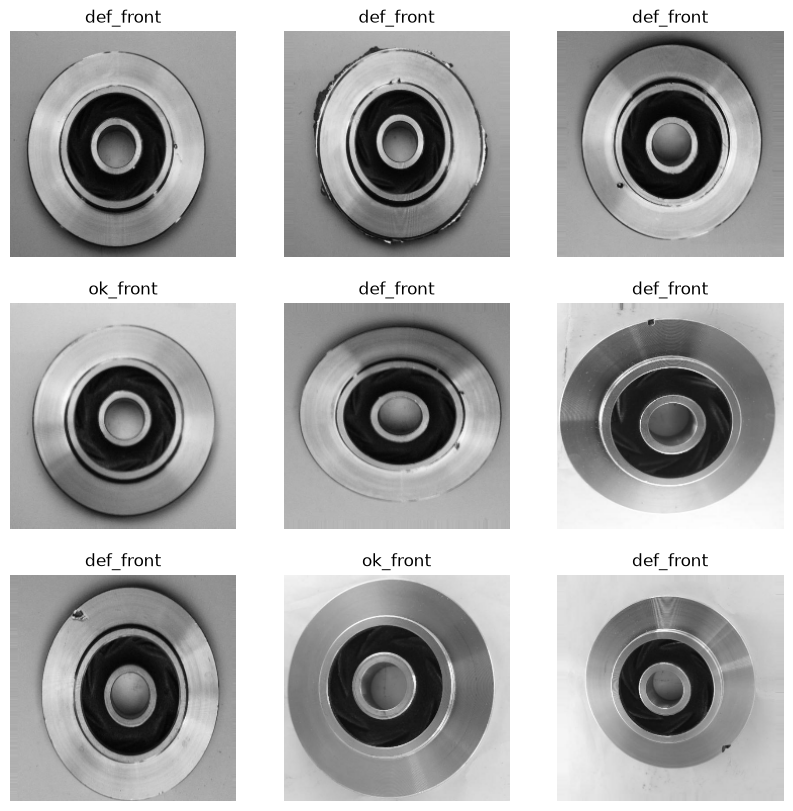

In [5]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [6]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x,y:(normalization_layer(x),y)
)

val_ds = val_ds.map(
    lambda x,y:(normalization_layer(x),y)
)

In [7]:
data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2)

])

In [8]:
model = Sequential([

    data_augmentation,

    layers.Conv2D(32,3,activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(1,activation="sigmoid")
])

In [23]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


checkpoint = ModelCheckpoint(
    filepath="best_casting_model.keras",   # File to save
    monitor="val_accuracy",                # Metric to monitor
    mode="max",                            # Higher accuracy is better
    save_best_only=True,                   # Save only the best model
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',      # Monitor validation accuracy
    patience=6,                  # Wait 3 epochs before stopping
    mode='max',                  # Higher accuracy is better
    restore_best_weights=True,   # Restore the best weights
    verbose=1
)

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8904 - loss: 0.2661
Epoch 1: val_accuracy improved from None to 0.94615, saving model to best_casting_model.keras

Epoch 1: finished saving model to best_casting_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 387ms/step - accuracy: 0.8904 - loss: 0.2661 - val_accuracy: 0.9462 - val_loss: 0.1533
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8962 - loss: 0.2294
Epoch 2: val_accuracy did not improve from 0.94615
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.8962 - loss: 0.2294 - val_accuracy: 0.8692 - val_loss: 0.2894
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9144 - loss: 0.2097
Epoch 3: val_accuracy did not improve from 0.94615
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step - accuracy: 0.9144 - loss: 0.2097 - val_accuracy: 0.9346 - val_loss: 0.1706
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9173 - loss: 0.2129
Epoch 4: val_accuracy did not improve from 0.94615
33/33 

In [25]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:",accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9654 - loss: 0.1103
Validation Accuracy: 0.9653846025466919


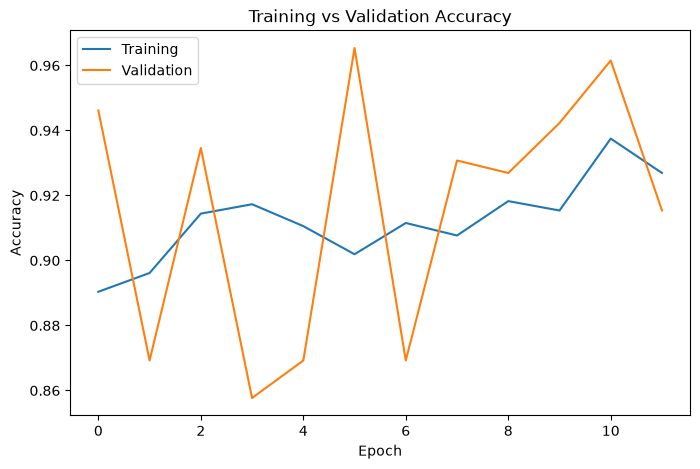

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

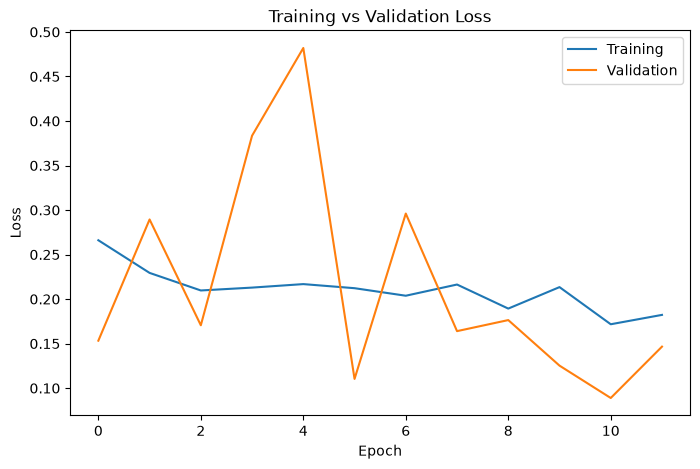

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training")

plt.plot(history.history["val_loss"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

In [28]:
model.save("casting_defect_detector.keras")

In [30]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "casting_512x512/ok_front/cast_ok_0_35.jpeg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(img_array,0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:

    print("OK Casting")

else:

    print("Defective Casting")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
OK Casting


In [31]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

y_true = np.concatenate([y for x,y in val_ds])

y_prob = model.predict(val_ds)

y_pred = (y_prob > 0.5).astype(int)

print(confusion_matrix(y_true,y_pred))

print(classification_report(y_true,y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
[[87 62]
 [65 46]]
              precision    recall  f1-score   support

           0       0.57      0.58      0.58       149
           1       0.43      0.41      0.42       111

    accuracy                           0.51       260
   macro avg       0.50      0.50      0.50       260
weighted avg       0.51      0.51      0.51       260

